## Build a Retrieval Augmented Generation (RAG) App

One of the most powerful applications enabled by LLMs is sophisticated question-answering (Q&A) chatbots. These are applications that can answer questions about specific source information. These applications use a technique known as Retrieval Augmented Generation, or RAG.

This tutorial will show how to build a simple Q&A application over a text data source. Along the way we’ll go over a typical Q&A architecture and highlight additional resources for more advanced Q&A techniques. We’ll also see how LangSmith can help us trace and understand our application. LangSmith will become increasingly helpful as our application grows in complexity.

In [1]:
%pip install --upgrade langchain-text-splitters langchain-community langgraph



Note: you may need to restart the kernel to use updated packages.


LangSmith
Many of the applications you build with LangChain will contain multiple steps with multiple invocations of LLM calls. As these applications get more and more complex, it becomes crucial to be able to inspect what exactly is going on inside your chain or agent. The best way to do this is with LangSmith.

After you sign up at the link above, make sure to set your environment variables to start logging traces:



In [2]:
import getpass
import os
import os
from dotenv import load_dotenv
load_dotenv()

LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"


In [3]:
!pip install -qU langchain-openai

In [4]:
# import os
# from dotenv import load_dotenv
# load_dotenv()
# from langchain_openai import AzureChatOpenAI

# AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
# AZURE_OPENAI_ENDPOINT=os.getenv("AZURE_OPENAI_ENDPOINT")
# AZURE_OPENAI_DEPLOYMENT_NAME=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
# AZURE_OPENAI_API_VERSION=os.getenv("AZURE_OPENAI_API_VERSION")
# os.environ["AZURE_OPENAI_API_KEY"] = AZURE_OPENAI_API_KEY
# llm = AzureChatOpenAI(
#     azure_endpoint=AZURE_OPENAI_ENDPOINT,
#     azure_deployment=AZURE_OPENAI_DEPLOYMENT_NAME,
#     openai_api_version=AZURE_OPENAI_API_VERSION,
# )



In [5]:
!pip install langchain-google-genai

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

gemini_api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = gemini_api_key
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-pro",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

/Users/macintosh/TA-DOCUMENT/StudyZone/FPT_WORK/IVY Training/IVY DEV/DailyReport/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print(llm.invoke("hello"))

content='Hello there! How can I help you today?' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []} id='run-c2fd161d-2dad-46ec-b266-7fcad0c2d943-0' usage_metadata={'input_tokens': 2, 'output_tokens': 11, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}}


In [8]:
!pip install -qU langchain-chroma

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.48.1 requires tokenizers<0.22,>=0.21, but you have tokenizers 0.20.3 which is incompatible.


In [9]:
!pip install -qU pypdf langchain_community



In [10]:
from langchain_community.document_loaders import PyPDFLoader
file_path = "/Users/macintosh/TA-DOCUMENT/StudyZone/FPT_WORK/IVY Training/IVY DEV/DailyReport/DL-3-21.1.2024/data/nike_dataset.pdf"
loader = PyPDFLoader(file_path)

docs = loader.load()

print(len(docs))



106


In [11]:
!pip install -qU langchain-huggingface

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 0.5.23 requires tokenizers<=0.20.3,>=0.13.2, but you have tokenizers 0.21.0 which is incompatible.


In [12]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [13]:
from langchain_chroma import Chroma

vector_store = Chroma(embedding_function=embeddings)

In [14]:
!pip install bs4

In [15]:
print(docs[10].page_content[:500])



Our DE&I focus extends beyond our workforce and includes our communities, which we support in a number of ways. We have 
committed to investments that aim to address racial inequality and improve diversity and representation in our communities. We 
also are leveraging our global scale to accelerate business diversity, including investing in business training programs for women 
and increasing the proportion of services supplied by minority-owned businesses.
COMPENSATION AND BENEFITS 
NIKE's tota


In [16]:
print(f"Total characters: {len(docs[70].page_content)}")

Total characters: 1094


In [17]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 501 sub-documents.


In [18]:
# Index chunks
_ = vector_store.add_documents(documents=all_splits)

In [19]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

### Retrieve with LangGraph

The state of our application controls what data is input to the application, transferred between steps, and output by the application.

In [20]:
from langchain_core.tools import tool


@tool(response_format="content_and_artifact")
def retrieve(query: str):
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

In [21]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode


# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"])
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]}


# Step 2: Execute the retrieval.
tools = ToolNode([retrieve])


# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

In [22]:
from langgraph.graph import END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

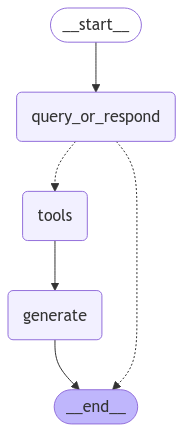

In [23]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
input_message = "Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello there! How can I help you today?


In [25]:
input_message = "What was Nike's revenue in 2023?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What was Nike's revenue in 2023?
================================== Ai Message ==================================
Tool Calls:
  retrieve (803fb2fc-8a06-4918-a8bd-f152c5d347d1)
 Call ID: 803fb2fc-8a06-4918-a8bd-f152c5d347d1
  Args:
    query: Nike revenue 2023
================================= Tool Message =================================
Name: retrieve

Source: {'page': 36, 'page_label': '37', 'source': '/Users/macintosh/TA-DOCUMENT/StudyZone/FPT_WORK/IVY Training/IVY DEV/DailyReport/DL-3-21.1.2024/data/nike_dataset.pdf', 'start_index': 0}
Content: FISCAL 2023 NIKE BRAND REVENUE HIGHLIGHTS
The following tables present NIKE Brand revenues disaggregated by reportable operating segment, distribution channel and 
major product line:
FISCAL 2023 COMPARED TO FISCAL 2022
• NIKE, Inc. Revenues were $51.2 billion in fiscal 2023, which increased 10% and 16% compared to fiscal 2022 on a reported 
and currency-neutr

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 Resource has been exhausted (e.g. check quota)..


ResourceExhausted: 429 Resource has been exhausted (e.g. check quota).

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [ ]:
input_message = "What was Nike's revenue in 2023?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What was Nike's revenue in 2023?
================================== Ai Message ==================================
Tool Calls:
  retrieve (45ea3de1-7aee-4b12-a6d1-b35f2b58b5e6)
 Call ID: 45ea3de1-7aee-4b12-a6d1-b35f2b58b5e6
  Args:
    query: Nike revenue 2023
================================= Tool Message =================================
Name: retrieve

Source: {'page': 36, 'page_label': '37', 'source': '/Users/macintosh/TA-DOCUMENT/StudyZone/FPT_WORK/IVY Training/IVY DEV/DailyReport/DL-3-21.1.2024/data/nike_dataset.pdf', 'start_index': 0}
Content: FISCAL 2023 NIKE BRAND REVENUE HIGHLIGHTS
The following tables present NIKE Brand revenues disaggregated by reportable operating segment, distribution channel and 
major product line:
FISCAL 2023 COMPARED TO FISCAL 2022
• NIKE, Inc. Revenues were $51.2 billion in fiscal 2023, which increased 10% and 16% compared to fiscal 2022 on a reported 
and currency-neutr

In [ ]:
input_message = "With this, is it the largest?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

With this, is it the largest?
================================== Ai Message ==================================
Tool Calls:
  retrieve (ade580cd-b655-461c-8fc2-cc3bdfef9425)
 Call ID: ade580cd-b655-461c-8fc2-cc3bdfef9425
  Args:
    query: Largest sportswear company by revenue 2023
================================= Tool Message =================================
Name: retrieve

Source: {'page': 90, 'page_label': '91', 'source': '/Users/macintosh/TA-DOCUMENT/StudyZone/FPT_WORK/IVY Training/IVY DEV/DailyReport/DL-3-21.1.2024/data/nike_dataset.pdf', 'start_index': 0}
Content: AS OF MAY 31,
(Dollars in millions) 2023 2022
ACCOUNTS RECEIVABLE, NET
North America $ 1,653 $ 1,850 
Europe, Middle East & Africa  1,197  1,351 
Greater China  162  406 
Asia Pacific & Latin America(1)  700  664 
Global Brand Divisions  96  113 
Total NIKE Brand  3,808  4,384 
Converse  235  230 
Corporate  88  53 
TOTAL ACCOUNTS RECEIVA

In [ ]:
!pip install langchain_together

In [29]:
# Querying chat models with Together AI
from langchain_together import ChatTogether
import os
from dotenv import load_dotenv
load_dotenv()

TOGETHER_API_KEY = os.getenv("TOGETHER_API_KEY")
os.environ["TOGETHER_API_KEY"] = TOGETHER_API_KEY
print(TOGETHER_API_KEY)
# choose from our 50+ models here: https://docs.together.ai/docs/inference-models
chat = ChatTogether(
    # together_api_key="YOUR_API_KEY",
    model="meta-llama/Llama-3-70b-chat-hf",
)

# stream the response back from the model
for m in chat.stream("Tell me fun things to do in NYC"):
    print(m.content, end="", flush=True)

# if you don't want to do streaming, you can use the invoke method
# chat.invoke("Tell me fun things to do in NYC")

b31e3ccbd7ba5d2732ea909df04877b4b567a6bdcd610ccff8faa79d0ae13ed1
The city that never sleeps! New York City is a treasure trove of excitement, entertainment, and adventure. Here are some fun things to do in NYC:

**Iconic Attractions:**

1. **Statue of Liberty and Ellis Island**: Take a ferry to Liberty Island to see the iconic statue up close and visit the Ellis Island Immigration Museum.
2. **Central Park**: A tranquil oasis in the middle of Manhattan, perfect for a stroll, picnic, or bike ride.
3. **Empire State Building**: For a panoramic view of the city, head to the observation deck of this iconic skyscraper.
4. **The Metropolitan Museum of Art**: One of the world's largest and most famous museums, with a collection that spans over 5,000 years of human history.

**Neighborhood Explorations:**

1. **SoHo**: Known for its trendy boutiques, art galleries, and cast-iron buildings.
2. **Greenwich Village**: A charming neighborhood with a rich history, known for its bohemian vibe, jazz 